## Step 1: Import Libraries

In [1]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Step 2: Import Dataset

In [2]:
claimants_data= pd.read_csv("Claimants.csv")
claimants_data.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


## Step 3: Data Understanding

In [3]:
claimants_data.shape

(1340, 7)

In [4]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [5]:
claimants_data.dropna(inplace=True)

In [6]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

In [7]:
claimants_data.describe()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
count,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000,1096.000000
mean,11244.278285,0.472628,0.564781,0.904197,0.018248,28.587591,3.856578
std,9425.386224,0.499478,0.496012,0.294455,0.133909,20.392621,10.473239
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4502.750000,0.000000,0.000000,1.000000,0.000000,9.000000,0.440000
50%,8730.500000,0.000000,1.000000,1.000000,0.000000,30.000000,1.311000
75%,16013.000000,1.000000,1.000000,1.000000,0.000000,43.000000,3.910500
max,34153.000000,1.000000,1.000000,1.000000,1.000000,95.000000,173.604000


In [8]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## Step 4: Data preparation

In [9]:
X=claimants_data[["CASENUM","CLMSEX","CLMINSUR","SEATBELT","CLMAGE","LOSS"]]
y=claimants_data["ATTORNEY"]

In [10]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,shuffle=True,random_state=37)

## Step 5: Model Building

In [11]:
Decision_model=DecisionTreeClassifier()

## Step 6: Model Training

In [12]:
Decision_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## Step 7: Model Testing

In [13]:
y_train_pred=Decision_model.predict(X_train)

In [14]:
y_test_pred=Decision_model.predict(X_test)

## Step 8: Model Evaluation

Training data evaluation metrics

In [15]:
error=y_train-y_train_pred
error

913     0
1232    0
1233    0
1333    0
887     0
       ..
536     0
1206    0
304     0
1037    0
439     0
Name: ATTORNEY, Length: 876, dtype: int64

In [16]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,roc_curve

In [17]:
accuracy_score(y_train,y_train_pred)

1.0

In [18]:
confusion_matrix(y_train,y_train_pred)

array([[461,   0],
       [  0, 415]])

In [19]:
classification_report(y_train,y_train_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00       461\n           1       1.00      1.00      1.00       415\n\n    accuracy                           1.00       876\n   macro avg       1.00      1.00      1.00       876\nweighted avg       1.00      1.00      1.00       876\n'

Testing data evaluation metrics

In [20]:
accuracy_score(y_test,y_test_pred)

0.6136363636363636

In [21]:
confusion_matrix(y_test,y_test_pred)

array([[77, 40],
       [45, 58]])

In [22]:
classification_report(y_test,y_test_pred)

'              precision    recall  f1-score   support\n\n           0       0.63      0.66      0.64       117\n           1       0.59      0.56      0.58       103\n\n    accuracy                           0.61       220\n   macro avg       0.61      0.61      0.61       220\nweighted avg       0.61      0.61      0.61       220\n'

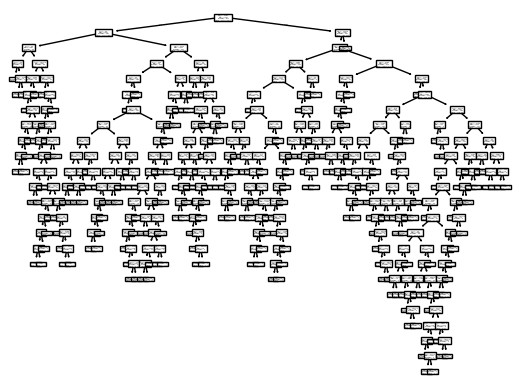

In [23]:
DT=plot_tree(Decision_model)
plt.show(DT)

GRID SEARCH

In [24]:
from sklearn.model_selection import GridSearchCV

In [25]:
gridsearch=GridSearchCV(Decision_model,param_grid={"max_depth":[5,6,7,8,9],"criterion":["gini_index","entropy"]})

In [26]:
gridsearch.fit(X_train,y_train)

C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
25 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "C:\Users\User\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py", l

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini_index', 'entropy'], 'max_depth': [5, 6, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [27]:
gridsearch.best_params_

{'criterion': 'entropy', 'max_depth': 5}

In [29]:
gridsearch.best_score_

np.float64(0.7123051948051948)